In [1]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd

data = pd.read_csv('/content/drive/MyDrive/datasets/Emotion_classify_Data.csv')
print(data.head())

                                             Comment Emotion
0  i seriously hate one subject to death but now ...    fear
1                 im so full of life i feel appalled   anger
2  i sit here to write i start to dig out my feel...    fear
3  ive been really angry with r and i feel like a...     joy
4  i feel suspicious if there is no one outside l...    fear


load your dataset

In [3]:
import os
os.listdir('/content/drive/MyDrive/datasets')

['Emotion_classify_Data.csv',
 'test.txt',
 '.ipynb_checkpoints',
 'happy.webp',
 'sad.webp',
 'angry.webp',
 'fear.webp',
 'surprise.webp']

Check column names


In [4]:
print(data.columns)

Index(['Comment', 'Emotion'], dtype='object')


Separate Input & Output

In [5]:
# The original purpose of this cell is to separate input (X) and output (y) for text classification.
X = data['Comment']
y = data['Emotion']
# To process an image URL, please use the interactive widgets provided earlier in the notebook.

Convert Text → Numbers

In [7]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()
X_vectorized = vectorizer.fit_transform(X)

Split Data (Train/Test)

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_vectorized, y, test_size=0.2, random_state=42
)

Train Model

In [9]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

Test Model


In [10]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8939393939393939


In [11]:
test_text = ["I am very happy today"]
test_vector = vectorizer.transform(test_text)

prediction = model.predict(test_vector)
print("Predicted Emotion:", prediction[0])

Predicted Emotion: joy


🧠 1. OpenCV (opencv-python)

This is your computer vision engine.

👉 What it does:

Reads images & videos (camera, files)
Detects faces, objects, edges
Draws shapes, boxes, text on images
Real-time processing (like webcam face detection)

💡 Example:

Detect a face from webcam
Convert image to grayscale
Track movement
🤖 2. TensorFlow

This is the brain for building AI models.

👉 What it does:

Builds and trains deep learning models
Works with neural networks (CNN, RNN, etc.)
Handles large-scale computations

💡 Example:

Train a model to recognize emotions from images
Build image classification systems
🧩 3. Keras

This is the easy interface for TensorFlow.

👉 What it does:

Simplifies model building
Lets you create neural networks in few lines
Runs on top of TensorFlow

💡 Example:

Define layers like:
Input → Convolution → Dense → Output
Train model with simple commands
😊 4. FER (fer)

FER = Facial Emotion Recognition library

👉 What it does:

Detects faces + predicts emotions
Uses pre-trained deep learning models
Gives outputs like:
Happy 😄
Sad 😢
Angry 😡
Surprise 😲

💡 Example:

Input: Face image
Output: Happy (0.92 confidence)
🔗 How they work together (VERY IMPORTANT)

Think like this:

OpenCV → Gets image from camera 📸
FER / TensorFlow model → Analyzes emotion 🧠
Keras → Helps build/train that model easily ⚙️

👉 Flow:

Camera → OpenCV → Face detected → Model (TensorFlow/Keras) → Emotion output (FER)

In [12]:
!pip install opencv-python tensorflow keras fer

INFO: pip is looking at multiple versions of facenet-pytorch to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 891.1/891.1 kB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 75.0 MB/s eta 0:00:00


Upload a Test Image

In [13]:
from google.colab import files
uploaded = files.upload()

Saving happy.webp to happy.webp


Read Image


(np.float64(-0.5), np.float64(353.5), np.float64(239.5), np.float64(-0.5))

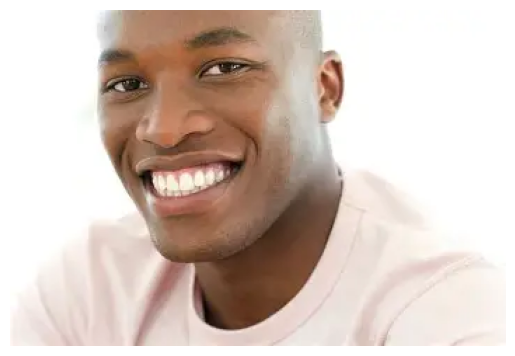

In [14]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('happy.webp')  # Changed to the uploaded file name
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis('off')

Detect Emotion

In [15]:
from fer.fer import FER

detector = FER()
result = detector.detect_emotions(img)

print(result)

[]


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Show Emotion on Image

(np.float64(-0.5), np.float64(353.5), np.float64(239.5), np.float64(-0.5))

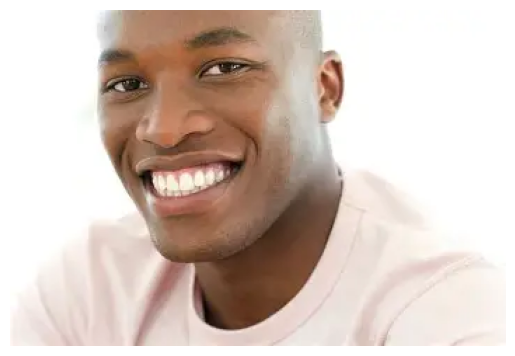

In [16]:
for face in result:
    (x, y, w, h) = face["box"]
    emotions = face["emotions"]

    emotion = max(emotions, key=emotions.get)

    cv2.rectangle(img, (x,y), (x+w,y+h), (0,255,0), 2)
    cv2.putText(img, emotion, (x,y-10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255,0,0), 2)

plt.imshow(img)
plt.axis('off')

In [17]:
img = cv2.resize(img, (600, 400))

In [18]:
from fer.fer import FER

detector = FER()
result = detector.detect_emotions(img)

print(result)

[]


In [19]:
detector = FER(mtcnn=True)

(400, 600, 3)


(np.float64(-0.5), np.float64(599.5), np.float64(399.5), np.float64(-0.5))

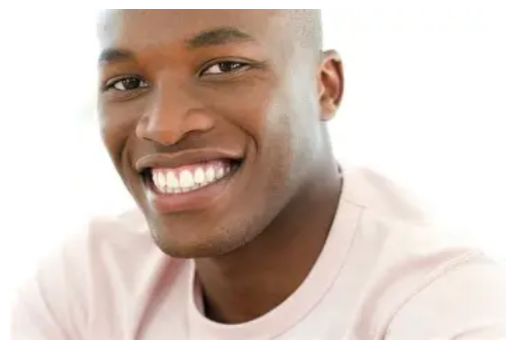

In [20]:
print(img.shape)
plt.imshow(img)
plt.axis('off')

In [22]:

from fer.fer import FER

detector = FER(mtcnn=True)   # IMPORTANT CHANGE
result = detector.detect_emotions(img)

print(result)

[{'box': [104, -94, 276, 380], 'emotions': {'angry': 0.0, 'disgust': 0.0, 'fear': 0.0, 'happy': 1.0, 'sad': 0.0, 'surprise': 0.0, 'neutral': 0.0}}]


In [23]:
if result:
    emotions = result[0]['emotions']
    emotion = max(emotions, key=emotions.get)
    print("Detected Emotion:", emotion)
else:
    print("Still no face detected")

Detected Emotion: happy


(np.float64(-0.5), np.float64(599.5), np.float64(399.5), np.float64(-0.5))

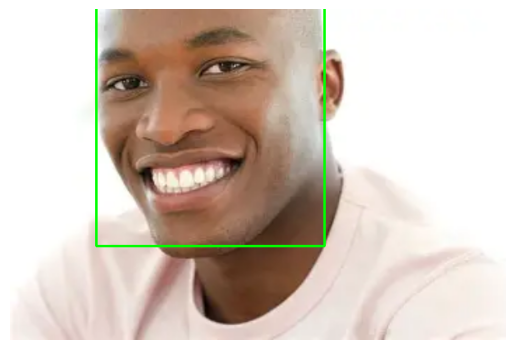

In [24]:
for face in result:
    (x, y, w, h) = face["box"]
    emotions = face["emotions"]

    emotion = max(emotions, key=emotions.get)

    # Draw rectangle
    cv2.rectangle(img, (x,y), (x+w,y+h), (0,255,0), 2)

    # Put text
    cv2.putText(img, emotion, (x,y-10),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (255,0,0), 2)

plt.imshow(img)
plt.axis('off')

External URL

(np.float64(-0.5), np.float64(2499.5), np.float64(2499.5), np.float64(-0.5))

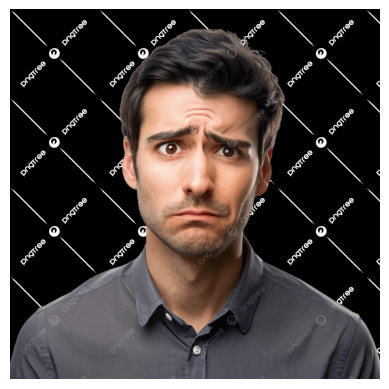

In [25]:
import cv2
import numpy as np
import requests
from matplotlib import pyplot as plt

# Paste your image URL here
url = "https://png.pngtree.com/png-clipart/20250104/original/pngtree-portrait-of-a-man-with-confused-questioning-facial-expression-displaying-skepticism-png-image_18709610.png"

# Read image from URL
resp = requests.get(url)
img_array = np.asarray(bytearray(resp.content), dtype=np.uint8)
img = cv2.imdecode(img_array, cv2.IMREAD_COLOR)

# Convert color
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis('off')

In [26]:
from fer.fer import FER

detector = FER(mtcnn=True)
result = detector.detect_emotions(img)

print(result)

[{'box': [835, 501, 863, 1132], 'emotions': {'angry': 0.29, 'disgust': 0.0, 'fear': 0.39, 'happy': 0.0, 'sad': 0.3, 'surprise': 0.01, 'neutral': 0.01}}]


In [27]:
if result:
    emotions = result[0]['emotions']
    emotion = max(emotions, key=emotions.get)
    print("Detected Emotion:", emotion)
else:
    print("Still no face detected")


Detected Emotion: fear


(np.float64(-0.5), np.float64(2499.5), np.float64(2499.5), np.float64(-0.5))

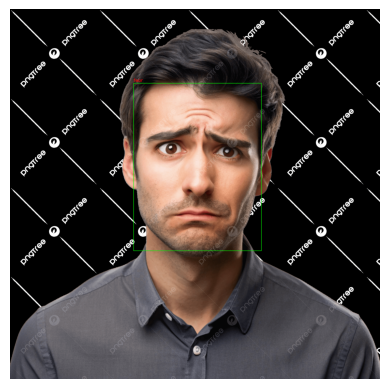

In [28]:
for face in result:
    (x, y, w, h) = face["box"]
    emotions = face["emotions"]

    emotion = max(emotions, key=emotions.get)

    # Draw rectangle
    cv2.rectangle(img, (x,y), (x+w,y+h), (0,255,0), 2)

    # Put text
    cv2.putText(img, emotion, (x,y-10),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (255,0,0), 2)

plt.imshow(img)
plt.axis('off')

Detects both when I upload a image from datasets it will detect emotion and when I add from google through link it also works
One limitaion is that it can detect 7 emotions if I add confusion simlar kind of emotions it wont detect

In [2]:
txt_path = "/content/drive/MyDrive/datasets/test.txt"

In [3]:
with open('/content/drive/MyDrive/datasets/test.txt', 'r') as file:
    lines = file.readlines()

print(lines[:5])   # show first 5 lines

['im feeling rather rotten so im not very ambitious right now;sadness\n', 'im updating my blog because i feel shitty;sadness\n', 'i never make her separate from me because i don t ever want her to feel like i m ashamed with her;sadness\n', 'i left with my bouquet of red and yellow tulips under my arm feeling slightly more optimistic than when i arrived;joy\n', 'i was feeling a little vain when i did this one;sadness\n']


In [4]:
import pandas as pd

data_txt = pd.read_csv(txt_path, names=["Comment", "Emotion"])
print(data_txt.head())

                                             Comment  Emotion
0  im feeling rather rotten so im not very ambiti...      NaN
1  im updating my blog because i feel shitty;sadness      NaN
2  i never make her separate from me because i do...      NaN
3  i left with my bouquet of red and yellow tulip...      NaN
4  i was feeling a little vain when i did this on...      NaN


In [5]:
data_txt = pd.read_csv(txt_path, sep='\t', names=["Emotion", "Comment"])
print(data_txt.head())

                                             Emotion  Comment
0  im feeling rather rotten so im not very ambiti...      NaN
1  im updating my blog because i feel shitty;sadness      NaN
2  i never make her separate from me because i do...      NaN
3  i left with my bouquet of red and yellow tulip...      NaN
4  i was feeling a little vain when i did this on...      NaN


In [6]:
import pandas as pd

data_txt = pd.read_csv(
    txt_path,
    sep=';',                # IMPORTANT FIX
    names=["Comment", "Emotion"]
)

print(data_txt.head())

                                             Comment  Emotion
0  im feeling rather rotten so im not very ambiti...  sadness
1          im updating my blog because i feel shitty  sadness
2  i never make her separate from me because i do...  sadness
3  i left with my bouquet of red and yellow tulip...      joy
4    i was feeling a little vain when i did this one  sadness


In [7]:
print(data_txt.columns)

Index(['Comment', 'Emotion'], dtype='object')


In [8]:
X = data_txt['Comment']
y = data_txt['Emotion']

In [9]:
from sklearn.feature_extraction.text import CountVectorizer

# Ensure X and y are correctly assigned from data_txt before vectorization
X = data_txt['Comment']
y = data_txt['Emotion']

vectorizer = CountVectorizer()
# Fill NaN values in X with empty strings before vectorizing
X_processed = X.fillna('')
X_vectorized = vectorizer.fit_transform(X_processed)

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

X_train, X_test, y_train, y_test = train_test_split(
    X_vectorized, y, test_size=0.2, random_state=42
)

model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

In [11]:
test_text = ["I feel very stressed and confused"]

test_vector = vectorizer.transform(test_text)
text_emotion = model.predict(test_vector)[0]

print("Text Emotion:", text_emotion)

Text Emotion: sadness


In [12]:
# Get image emotion from the result of the last image detection
if 'result' in locals() and result:
    emotions_from_image = result[0]['emotions']
    image_emotion = max(emotions_from_image, key=emotions_from_image.get)
else:
    image_emotion = "unknown" # Default if no face detected in the last image

# Define risky emotions
risky = ['anger', 'fear', 'sadness']

# Combine logic
if image_emotion in risky or text_emotion in risky:
    final_result = "⚠️ Alert: High-risk emotional state detected"
else:
    final_result = "✅ Normal emotional state"

print("\n----- FINAL RESULT -----")
print("Image Emotion:", image_emotion)
print("Text Emotion:", text_emotion)
print(final_result)


----- FINAL RESULT -----
Image Emotion: unknown
Text Emotion: sadness
⚠️ Alert: High-risk emotional state detected


ipywidgets

This one’s all about making your Jupyter Notebook interactive instead of just static code.

🚀 What it does

ipywidgets lets you add UI controls inside notebooks like:

Sliders 🎚️
Buttons 🔘
Dropdowns ⬇️
Text boxes ⌨️

So instead of hardcoding values, users can interact live.

💡 Simple idea

Without widgets:

threshold = 0.5

With widgets:
👉 User can move a slider to change threshold in real time!

In [13]:
!pip install ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 21.6 MB/s eta 0:00:00


In [14]:
import cv2
import numpy as np
import requests
import matplotlib.pyplot as plt

import ipywidgets as widgets
from IPython.display import display

In [15]:
def run_text_emotion(b):
    global vectorizer, model # Declare global variables
    text = text_input.value

    # -------- validation --------
    if not text or text.strip() == "":
        print("⚠️ Please enter a sentence")
        return

    print("\n💬 Input Text:", text)

    # -------- vectorize --------
    text_vector = vectorizer.transform([text])

    # -------- prediction --------
    prediction = model.predict(text_vector)[0]

    print("🎯 Predicted Emotion:", prediction)

In [16]:
text_input = widgets.Text(description='Your Text:')

text_button = widgets.Button(description="Detect Emotion 🚀")
text_button.on_click(run_text_emotion)

display(text_input, text_button)

Text(value='', description='Your Text:')

Button(description='Detect Emotion 🚀', style=ButtonStyle())

In [17]:
!pip install fer
import cv2
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
from fer.fer import FER # Corrected import statement

# ---------------- UI COMPONENTS ----------------

title = widgets.HTML("<h2 style='color:#4CAF50'>🧠 Multimodal Emotion AI System</h2>")

upload_widget = widgets.FileUpload(
    accept='image/*',
    multiple=False
)

text_input = widgets.Text(
    placeholder='Type or paste your sentence...',
    description='Text:',
    layout=widgets.Layout(width='500px')
)

run_button = widgets.Button(
    description="Analyze Emotion 🚀",
    button_style='success',
    layout=widgets.Layout(width='200px')
)

output = widgets.Output()

ui = widgets.VBox([
    title,
    upload_widget,
    text_input,
    run_button,
    output
])

display(ui)

# ---------------- CORE FUNCTION ----------------

def run_system(b):
    global image_emotion, text_emotion

    with output:
        clear_output()

        print("🔍 Running Emotion Analysis...\n")

        # ---------------- IMAGE PART ----------------
        if upload_widget.value:
            file_info = list(upload_widget.value.values())[0]
            content = file_info['content']

            np_arr = np.frombuffer(content, np.uint8)
            img = cv2.imdecode(np_arr, cv2.IMREAD_COLOR)

            if img is None:
                print("❌ Image decode failed")
                return

            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            plt.imshow(img)
            plt.axis('off')
            plt.show()

            detector = FER(mtcnn=True)
            result = detector.detect_emotions(img)

            if result:
                emotions = result[0]['emotions']
                image_emotion = max(emotions, key=emotions.get)
            else:
                image_emotion = "unknown"

        else:
            print("⚠️ Please upload image")
            return

        print("🖼️ Image Emotion:", image_emotion)

        # ---------------- TEXT PART ----------------
        text = text_input.value

        if not text or text.strip() == "":
            print("⚠️ Enter text input")
            return

        vector = vectorizer.transform([text])
        text_emotion = model.predict(vector)[0]

        print("💬 Text Emotion:", text_emotion)

        # ---------------- FUSION LOGIC ----------------
        risky = ["anger", "fear", "sadness"]

        if image_emotion == text_emotion:
            final_result = f"✅ Strong {image_emotion} detected (aligned signals)"

        elif image_emotion in risky and text_emotion in risky:
            final_result = "⚠️ High negative emotion (conflicting stress signals)"

        elif image_emotion in risky or text_emotion in risky:
            final_result = "⚠️ Negative emotional state detected"

        else:
            final_result = "😊 Positive / Neutral emotional state"

        print("\n🎯 FINAL RESULT:", final_result)

        # Beautiful output box
        display(HTML(f"""
        <div style="
            padding:15px;
            border-radius:12px;
            background:#f5f5f5;
            border-left:6px solid #4CAF50;
            font-size:16px;">
            {final_result}
        </div>
        """))

# ---------------- BUTTON ACTION ----------------

run_button.on_click(run_system)


In [24]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

Plot confusion matrix

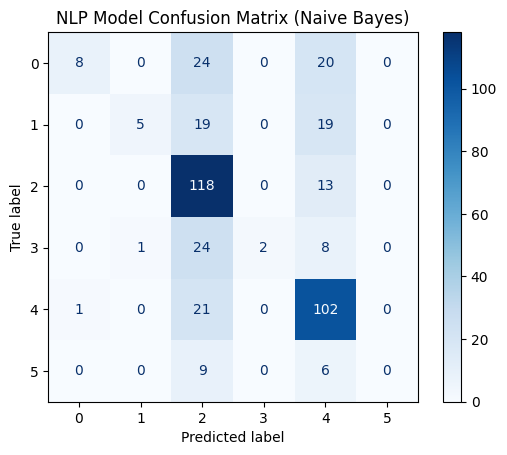

In [26]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(X_test) # Calculate y_pred for the current model and X_test
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("NLP Model Confusion Matrix (Naive Bayes)")
plt.show()

NLP CONFIDENCE GRAPH

In [27]:
import numpy as np

sample = X_test[:10]
probs = model.predict_proba(sample)

print("Sample confidence scores:\n")
for i in range(10):
    print("Text:", X_test[i])
    print("Confidence:", max(probs[i]))
    print("-"*50)

Sample confidence scores:

Text: <Compressed Sparse Row sparse matrix of dtype 'int64'
	with 39 stored elements and shape (1, 4778)>
  Coords	Values
  (0, 3854)	2
  (0, 1552)	1
  (0, 2598)	1
  (0, 4269)	1
  (0, 160)	2
  (0, 272)	1
  (0, 4203)	4
  (0, 1651)	1
  (0, 583)	1
  (0, 2228)	1
  (0, 4723)	1
  (0, 4597)	1
  (0, 1756)	1
  (0, 119)	1
  (0, 2945)	1
  (0, 4389)	1
  (0, 84)	1
  (0, 503)	1
  (0, 2739)	1
  (0, 1027)	1
  (0, 2436)	2
  (0, 4706)	1
  (0, 2595)	1
  (0, 1922)	1
  (0, 4475)	2
  (0, 4623)	1
  (0, 1048)	1
  (0, 1159)	1
  (0, 566)	1
  (0, 3748)	1
  (0, 423)	1
  (0, 3914)	1
  (0, 4124)	1
  (0, 2521)	1
  (0, 731)	1
  (0, 2688)	1
  (0, 3128)	1
  (0, 3957)	1
  (0, 1434)	1
Confidence: 0.9600636200706899
--------------------------------------------------
Text: <Compressed Sparse Row sparse matrix of dtype 'int64'
	with 13 stored elements and shape (1, 4778)>
  Coords	Values
  (0, 1552)	1
  (0, 2598)	1
  (0, 2885)	1
  (0, 160)	1
  (0, 4203)	1
  (0, 2911)	1
  (0, 4107)	1
  (0, 1984)	1


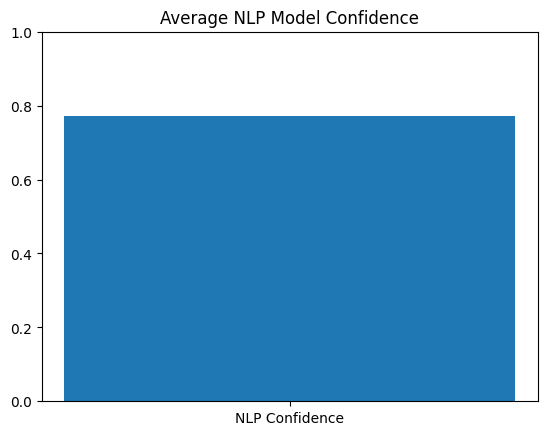

In [28]:
import matplotlib.pyplot as plt

avg_conf = np.mean(np.max(model.predict_proba(X_test), axis=1))

plt.bar(["NLP Confidence"], [avg_conf])
plt.ylim(0, 1)
plt.title("Average NLP Model Confidence")
plt.show()